<a href="https://colab.research.google.com/github/kaung-min-thant/SubImpact-AI/blob/main/SubImpact_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#Install Dependencies
!pip install statsbombpy scikit-learn xgboost lightgbm shap pandas numpy matplotlib seaborn --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.8/63.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.6 MB/s eta 0:00:00


In [5]:
#Import Libraries
import pandas as pd
import numpy as np
import warnings
import os

from statsbombpy import sb

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

In [6]:
#Configuration
# COMPETITIONS = [
#     {"competition_id": 43, "season_id": 106, "name": "FIFA World Cup 2022"},
#     {"competition_id": 55, "season_id": 282, "name": "UEFA Euro 2024"},
#     {"competition_id": 9,  "season_id": 281, "name": "Bundesliga 2023/2024"},
#     {"competition_id": 1267, "season_id": 107, "name": "African Cup of Nations 2023"},
#     {"competition_id": 53, "season_id": 315, "name": "UEFA Women's Euro 2025"},
#     {"competition_id": 7,  "season_id": 235, "name": "Ligue 1 2022/2023"},
#     {"competition_id": 43,  "season_id": 3,   "name": "FIFA World Cup 2018"},
#     {"competition_id": 72,  "season_id": 107, "name": "Women's World Cup 2023"},
#     {"competition_id": 223, "season_id": 282, "name": "Copa America 2024"},
# ]
COMPETITIONS = [
    {"competition_id": 9,  "season_id": 281, "name": "Bundesliga 2023/2024"},
    {"competition_id": 11, "season_id": 90,  "name": "La Liga 2020/2021"},
    {"competition_id": 7,  "season_id": 235, "name": "Ligue 1 2022/2023"},
    {"competition_id": 2,  "season_id": 27,  "name": "Premier League 2015/2016"},
    {"competition_id": 12, "season_id": 27,  "name": "Serie A 2015/2016"},
    {"competition_id": 43, "season_id": 106, "name": "FIFA World Cup 2022"},
]
WINDOW_MIN   = 15
MIN_POST_MIN = 5
IMPACT_POS_THRESHOLD =  0.10
IMPACT_NEG_THRESHOLD = -0.10

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Config set. Window={WINDOW_MIN}min | Thresholds: +{IMPACT_POS_THRESHOLD} / {IMPACT_NEG_THRESHOLD}")

Config set. Window=15min | Thresholds: +0.1 / -0.1


In [7]:
#Helper functions
def get_score_at_minute(events_df, team_name, minute):
    goals = events_df[
        (events_df["type"] == "Shot") &
        (events_df["shot_outcome"] == "Goal") &
        (events_df["minute"] < minute)
    ]
    team_goals = goals[goals["team"] == team_name].shape[0]
    opp_goals  = goals[goals["team"] != team_name].shape[0]
    return team_goals, opp_goals

def get_xg_in_window(events_df, team_name, start_min, end_min):
    window = events_df[
        (events_df["type"] == "Shot") &
        (events_df["minute"] >= start_min) &
        (events_df["minute"] < end_min)
    ].copy()
    team_xg = window[window["team"] == team_name]["shot_statsbomb_xg"].sum()
    opp_xg  = window[window["team"] != team_name]["shot_statsbomb_xg"].sum()
    return round(team_xg, 4), round(opp_xg, 4)

def get_event_counts_in_window(events_df, team_name, start_min, end_min):
    window = events_df[
        (events_df["team"] == team_name) &
        (events_df["minute"] >= start_min) &
        (events_df["minute"] < end_min)
    ]
    shots     = (window["type"] == "Shot").sum()
    passes    = (window["type"] == "Pass").sum()
    pressures = (window["type"] == "Pressure").sum()
    return int(shots), int(passes), int(pressures)

def get_position_group(position_name):
    if not position_name:
        return "Unknown"
    pos = position_name.lower()
    if any(p in pos for p in ["forward", "wing", "striker", "second striker"]):
        return "FW"
    elif any(p in pos for p in ["midfield", "attacking mid", "defensive mid"]):
        return "MF"
    elif any(p in pos for p in ["back", "sweeper", "wing back"]):
        return "DF"
    elif "goalkeeper" in pos or "keeper" in pos:
        return "GK"
    else:
        return "Unknown"

def get_game_phase(minute):
    if minute <= 30:
        return "0-30"
    elif minute <= 60:
        return "31-60"
    elif minute <= 75:
        return "61-75"
    else:
        return "76-90+"

def classify_impact(score):
    if score > IMPACT_POS_THRESHOLD:
        return "Positive"
    elif score < IMPACT_NEG_THRESHOLD:
        return "Negative"
    else:
        return "Neutral"

In [8]:
#Load All Matches
print("\nLoading match lists from StatsBomb...")
all_matches = []

for comp in COMPETITIONS:
    try:
        matches = sb.matches(
            competition_id=comp["competition_id"],
            season_id=comp["season_id"]
        )
        matches["competition_name"] = comp["name"]
        all_matches.append(matches)
        print(f"{comp['name']}: {len(matches)} matches")
    except Exception as e:
        print(f"FAILED: {comp['name']}: {e}")

matches_df = pd.concat(all_matches, ignore_index=True)
print(f"\nTotal matches loaded: {len(matches_df)}")


Loading match lists from StatsBomb...
Bundesliga 2023/2024: 34 matches
La Liga 2020/2021: 35 matches
Ligue 1 2022/2023: 32 matches
Premier League 2015/2016: 380 matches
Serie A 2015/2016: 380 matches
FIFA World Cup 2022: 64 matches

Total matches loaded: 925


In [9]:
print("\nExtracting substitution-level features...")
records = []
failed  = 0
match_ids = matches_df["match_id"].tolist()

i = 0
for match_id in match_ids:

    if i % 20 == 0:
        print(f"   Progress: {i}/{len(match_ids)} matches | Samples so far: {len(records)}")
    i += 1

    try:
        events = sb.events(match_id=match_id)

        # Normalize columns
        if "type" in events.columns and events["type"].dtype == object:
            if type(events["type"].iloc[0]) == dict:
                events["type"] = events["type"].apply(lambda x: x.get("name", "") if type(x) == dict else x)

        if "shot_outcome" in events.columns and events["shot_outcome"].dtype == object:
            if type(events["shot_outcome"].dropna().iloc[0]) == dict:
                events["shot_outcome"] = events["shot_outcome"].apply(
                    lambda x: x.get("name", "") if type(x) == dict else x
                )

        if "team" in events.columns and events["team"].dtype == object:
            if type(events["team"].iloc[0]) == dict:
                events["team"] = events["team"].apply(lambda x: x.get("name", "") if type(x) == dict else x)

        if "shot_statsbomb_xg" not in events.columns:
            events["shot_statsbomb_xg"] = 0.0
        events["shot_statsbomb_xg"] = pd.to_numeric(events["shot_statsbomb_xg"], errors="coerce").fillna(0.0)

        subs = events[events["type"] == "Substitution"].copy()
        if subs.empty:
            continue

        match_row  = matches_df[matches_df["match_id"] == match_id].iloc[0]
        home_team  = match_row.get("home_team", {})
        if type(home_team) == dict:
            home_team = home_team.get("home_team_name", "")

        match_minute_max = events["minute"].max()
        sub_seq_tracker = {}

        for _, sub in subs.iterrows():
            sub_min  = int(sub["minute"])
            team     = sub["team"] if type(sub["team"]) == str else sub["team"].get("name", "")

            if not team:
                continue

            time_remaining = 90 - sub_min
            if time_remaining < MIN_POST_MIN:
                continue

            raw_position = sub.get("position", None)
            if type(raw_position) == dict:
                position_name = raw_position.get("name", "")
            elif type(raw_position) == str:
                position_name = raw_position
            else:
                position_name = ""
            position_group = get_position_group(position_name)

            sub_seq_tracker[team] = sub_seq_tracker.get(team, 0) + 1
            sub_sequence = sub_seq_tracker[team]

            pre_start = max(0, sub_min - WINDOW_MIN)
            pre_end   = sub_min

            team_xg_prev, opp_xg_prev = get_xg_in_window(events, team, pre_start, pre_end)
            shots_prev, passes_prev, pressures_prev = get_event_counts_in_window(
                events, team, pre_start, pre_end
            )
            team_goals, opp_goals = get_score_at_minute(events, team, sub_min)
            score_diff   = team_goals - opp_goals
            is_home      = 1 if team == home_team else 0
            xg_diff_prev = round(team_xg_prev - opp_xg_prev, 4)

            post_start = sub_min
            post_end   = min(sub_min + WINDOW_MIN, int(match_minute_max) + 1)

            team_xg_next, opp_xg_next = get_xg_in_window(events, team, post_start, post_end)
            xg_diff_next = round(team_xg_next - opp_xg_next, 4)

            impact_score = round(xg_diff_next - xg_diff_prev, 4)
            impact_label = classify_impact(impact_score)

            records.append({
                "match_id":         match_id,
                "competition":      match_row.get("competition_name", ""),
                "team":             team,
                "sub_minute":       sub_min,
                "score_diff":       score_diff,
                "is_home":          is_home,
                "time_remaining":   time_remaining,
                "sub_sequence":     sub_sequence,
                "game_phase":       get_game_phase(sub_min),
                "position_name":    position_name,
                "position_group":   position_group,
                "team_xg_prev15":   team_xg_prev,
                "opp_xg_prev15":    opp_xg_prev,
                "xg_diff_prev15":   xg_diff_prev,
                "shots_prev15":     shots_prev,
                "passes_prev15":    passes_prev,
                "pressures_prev15": pressures_prev,
                "team_xg_next15":   team_xg_next,
                "opp_xg_next15":    opp_xg_next,
                "xg_diff_next15":   xg_diff_next,
                "impact_score":     impact_score,
                "impact_label":     impact_label,
            })

    except Exception as e:
        failed += 1
        continue

print(f"\nExtraction complete!")
print(f"   Total substitution samples: {len(records)}")
print(f"   Failed matches (skipped):   {failed}")


Extracting substitution-level features...
   Progress: 0/925 matches | Samples so far: 0
   Progress: 20/925 matches | Samples so far: 150
   Progress: 40/925 matches | Samples so far: 310
   Progress: 60/925 matches | Samples so far: 462
   Progress: 80/925 matches | Samples so far: 627
   Progress: 100/925 matches | Samples so far: 772
   Progress: 120/925 matches | Samples so far: 873
   Progress: 140/925 matches | Samples so far: 973
   Progress: 160/925 matches | Samples so far: 1073
   Progress: 180/925 matches | Samples so far: 1168
   Progress: 200/925 matches | Samples so far: 1267
   Progress: 220/925 matches | Samples so far: 1359
   Progress: 240/925 matches | Samples so far: 1459
   Progress: 260/925 matches | Samples so far: 1562
   Progress: 280/925 matches | Samples so far: 1662
   Progress: 300/925 matches | Samples so far: 1753
   Progress: 320/925 matches | Samples so far: 1855
   Progress: 340/925 matches | Samples so far: 1946
   Progress: 360/925 matches | Sample

In [10]:
df = pd.DataFrame(records)

print("Dataset Overview:")
print(f"   Shape: {df.shape}")

print("\nImpact Label Distribution:")
print(df["impact_label"].value_counts())

print("\nLabel Percentages:")
print(df["impact_label"].value_counts(normalize=True).round(3) * 100)

print("\nPosition Group Distribution:")
print(df["position_group"].value_counts())

# Encode game phase as number
phase_map = {"0-30": 0, "31-60": 1, "61-75": 2, "76-90+": 3}
df["game_phase_enc"] = df["game_phase"].map(phase_map)

# Encode position group as number
position_map = {"FW": 0, "MF": 1, "DF": 2, "GK": 3, "Unknown": 4}
df["position_group_enc"] = df["position_group"].map(position_map)

# Save to CSV
import os
os.makedirs("outputs", exist_ok=True)
df.to_csv("outputs/substitutions_phase1_raw.csv", index=False)

print("\nDataset saved to outputs/substitutions_phase1_raw.csv")

Dataset Overview:
   Shape: (5207, 22)

Impact Label Distribution:
impact_label
Positive    2274
Negative    1872
Neutral     1061
Name: count, dtype: int64

Label Percentages:
impact_label
Positive   43.7000
Negative   36.0000
Neutral    20.4000
Name: proportion, dtype: float64

Position Group Distribution:
position_group
MF    2315
FW    2168
DF     709
GK      15
Name: count, dtype: int64

Dataset saved to outputs/substitutions_phase1_raw.csv


In [11]:
print("Training baseline models...")

FEATURE_COLS = [
    "score_diff", "is_home", "time_remaining",
    "sub_sequence", "game_phase_enc",
    "position_group_enc",
    "team_xg_prev15", "opp_xg_prev15", "xg_diff_prev15",
    "shots_prev15", "passes_prev15", "pressures_prev15",
]

TARGET_COL = "impact_label"

model_df = df[FEATURE_COLS + [TARGET_COL]].dropna()
print(f"   Samples used for modeling: {len(model_df)}")

X = model_df[FEATURE_COLS].values
y = model_df[TARGET_COL].values

le = LabelEncoder()
y_enc = le.fit_transform(y)
print(f"   Label classes: {le.classes_}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.20, random_state=42, stratify=y_enc
)
print(f"   Train size: {len(X_train)} | Test size: {len(X_test)}")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


def evaluate_model(name, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)
    auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    print(f"   Accuracy  : {acc:.4f}")
    print(f"   Macro F1  : {f1:.4f}")
    print(f"   Macro AUC : {auc:.4f}")
    print("-" * 55)
    print(classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0))
    return {"model": name, "accuracy": acc, "macro_f1": f1, "macro_auc": auc}

results = []

Training baseline models...
   Samples used for modeling: 5207
   Label classes: ['Negative' 'Neutral' 'Positive']
   Train size: 4165 | Test size: 1042


In [12]:
# Baseline 1: Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr.fit(X_train_sc, y_train)
lr_pred = lr.predict(X_test_sc)
lr_prob = lr.predict_proba(X_test_sc)
results.append(evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob))


Training Logistic Regression...
   Accuracy  : 0.5701
   Macro F1  : 0.5606
   Macro AUC : 0.7698
-------------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.70      0.58      0.63       375
     Neutral       0.32      0.59      0.41       212
    Positive       0.75      0.55      0.64       455

    accuracy                           0.57      1042
   macro avg       0.59      0.57      0.56      1042
weighted avg       0.64      0.57      0.59      1042



In [13]:
# Baseline 2: Random Forest
print("\nTraining Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200, max_depth=8,
    class_weight="balanced", random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)
results.append(evaluate_model("Random Forest", y_test, rf_pred, rf_prob))


Training Random Forest...
   Accuracy  : 0.6132
   Macro F1  : 0.5935
   Macro AUC : 0.8006
-------------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.70      0.61      0.65       375
     Neutral       0.38      0.55      0.45       212
    Positive       0.72      0.65      0.68       455

    accuracy                           0.61      1042
   macro avg       0.60      0.60      0.59      1042
weighted avg       0.64      0.61      0.62      1042



In [14]:
results_df = pd.DataFrame(results)

print("-" * 55)
print("PHASE 1 RESULTS SUMMARY - Baseline Metrics")
print("-" * 55)
print(results_df.to_string(index=False))

-------------------------------------------------------
PHASE 1 RESULTS SUMMARY - Baseline Metrics
-------------------------------------------------------
              model  accuracy  macro_f1  macro_auc
Logistic Regression    0.5701    0.5606     0.7698
      Random Forest    0.6132    0.5935     0.8006


In [15]:
# # Checking the number of matches available for each leauge in statsbombpy

# from statsbombpy import sb
# import pandas as pd

# all_comps = sb.competitions()

# match_counts = []

# # 1. Loop through each row to fetch matches and count them
# for idx, row in all_comps.iterrows():
#     comp_id = row["competition_id"]
#     season_id = row["season_id"]
#     comp_name = row["competition_name"]
#     season_name = row["season_name"]

#     try:
#         # Fetch matches for this specific competition and season
#         matches = sb.matches(competition_id=comp_id, season_id=season_id)
#         num_matches = len(matches)
#     except Exception:
#         # Handles instances where API access might be restricted for certain comps
#         num_matches = 0

#     match_counts.append({
#         "competition_id": comp_id,
#         "season_id": season_id,
#         "competition_name": comp_name,
#         "season_name": season_name,
#         "match_count": num_matches
#     })

# # 2. Turn it into a clean DataFrame and print
# counts_df = pd.DataFrame(match_counts)
# print(counts_df.to_string(index=False))

In [16]:
import json
import joblib

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    XGBOOST_IMPORT_ERROR = e

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except Exception as e:
    LIGHTGBM_AVAILABLE = False
    LIGHTGBM_IMPORT_ERROR = e

print(f"XGBoost available: {XGBOOST_AVAILABLE}")
print(f"LightGBM available: {LIGHTGBM_AVAILABLE}")

XGBoost available: True
LightGBM available: True


In [17]:
df_phase2 = df.copy()

competition_map = {name: idx for idx, name in enumerate(sorted(df_phase2["competition"].unique()))}
df_phase2["competition_enc"] = df_phase2["competition"].map(competition_map)

df_phase2["abs_score_diff"] = df_phase2["score_diff"].abs()
df_phase2["is_trailing"] = (df_phase2["score_diff"] < 0).astype(int)
df_phase2["is_leading"] = (df_phase2["score_diff"] > 0).astype(int)
df_phase2["late_sub"] = (df_phase2["sub_minute"] >= 60).astype(int)
df_phase2["very_late_sub"] = (df_phase2["sub_minute"] >= 75).astype(int)

df_phase2["xg_per_shot_prev15"] = (
    df_phase2["team_xg_prev15"] / df_phase2["shots_prev15"].replace(0, np.nan)
).fillna(0)

df_phase2["pressure_per_pass_prev15"] = (
    df_phase2["pressures_prev15"] / df_phase2["passes_prev15"].replace(0, np.nan)
).fillna(0)

df_phase2["passes_per_min_prev15"] = df_phase2["passes_prev15"] / WINDOW_MIN
df_phase2["pressures_per_min_prev15"] = df_phase2["pressures_prev15"] / WINDOW_MIN
df_phase2["shots_per_min_prev15"] = df_phase2["shots_prev15"] / WINDOW_MIN

In [18]:
POSITION_GROUPS = ["FW", "MF", "DF", "GK"]
POSITION_METRICS = ["passes", "pressures", "shots", "xg"]

def clean_name(value):
    if isinstance(value, dict):
        return value.get("name", "")
    if value is None:
        return ""
    try:
        if pd.isna(value):
            return ""
    except (TypeError, ValueError):
        pass
    return str(value)

def prepare_events(events):
    events = events.copy()
    for col in ["type", "team", "player", "position", "pass_outcome", "substitution_replacement"]:
        if col not in events.columns:
            events[col] = ""
        events[col] = events[col].apply(clean_name)

    if "shot_statsbomb_xg" not in events.columns:
        events["shot_statsbomb_xg"] = 0.0
    events["shot_statsbomb_xg"] = pd.to_numeric(events["shot_statsbomb_xg"], errors="coerce").fillna(0.0)
    events["minute"] = pd.to_numeric(events["minute"], errors="coerce").fillna(0).astype(int)
    return events

def player_window(events, team, player, start_min, end_min):
    minutes = max(end_min - start_min, 1)

    team_window = events[
        (events["team"] == team) &
        (events["minute"] >= start_min) &
        (events["minute"] < end_min)
    ]

    player_window = team_window[team_window["player"] == player] if player else team_window.iloc[0:0]

    passes = player_window[player_window["type"] == "Pass"]
    pass_attempts = len(passes)
    pass_successes = (passes["pass_outcome"] == "").sum()
    pass_success_rate = pass_successes / pass_attempts if pass_attempts else 0

    pressures = (player_window["type"] == "Pressure").sum()
    actions = len(player_window)
    team_actions = len(team_window)

    return {
        "pass_attempts": pass_attempts,
        "pass_success_rate": pass_success_rate,
        "pressures": pressures,
        "pressure_rate": pressures / minutes,
        "actions": actions,
        "action_rate": actions / minutes,
        "involvement_share": actions / team_actions if team_actions else 0,
    }

def position_window_features(events, team, start_min, end_min, suffix):
    window = events[
        (events["team"] == team) &
        (events["minute"] >= start_min) &
        (events["minute"] < end_min)
    ].copy()

    if window.empty:
        return {
            f"{group}_{metric}_{suffix}": 0
            for group in POSITION_GROUPS
            for metric in POSITION_METRICS
        }

    window["event_position_group"] = window["position"].apply(get_position_group)
    features = {}

    for group in POSITION_GROUPS:
        group_window = window[window["event_position_group"] == group]
        shots = group_window[group_window["type"] == "Shot"]

        features[f"{group}_passes_{suffix}"] = int((group_window["type"] == "Pass").sum())
        features[f"{group}_pressures_{suffix}"] = int((group_window["type"] == "Pressure").sum())
        features[f"{group}_shots_{suffix}"] = int(len(shots))
        features[f"{group}_xg_{suffix}"] = round(shots["shot_statsbomb_xg"].sum(), 4)

    return features

In [19]:
fatigue_records = []
failed_phase2_matches = 0

for i, match_id in enumerate(matches_df["match_id"].tolist()):
    if i % 25 == 0:
        print(f"Progress: {i}/{len(matches_df)} matches")

    try:
        events = prepare_events(sb.events(match_id=match_id))
        subs = events[events["type"] == "Substitution"].copy()
        match_minute_max = int(events["minute"].max())

        sub_seq_tracker = {}

        for _, sub in subs.iterrows():
            sub_min = int(sub["minute"])
            team = sub["team"]

            if not team:
                continue
            if 90 - sub_min < MIN_POST_MIN:
                continue

            sub_seq_tracker[team] = sub_seq_tracker.get(team, 0) + 1
            sub_sequence = sub_seq_tracker[team]

            player = sub["player"]
            replacement = sub["substitution_replacement"]

            recent = player_window(events, team, player, max(0, sub_min - WINDOW_MIN), sub_min)
            prior = player_window(events, team, player, max(0, sub_min - 2 * WINDOW_MIN), max(0, sub_min - WINDOW_MIN))

            position_prev = position_window_features(events, team, max(0, sub_min - WINDOW_MIN), sub_min, "prev15")
            position_next = position_window_features(events, team, sub_min, min(sub_min + WINDOW_MIN, match_minute_max + 1), "next15")

            fatigue_records.append({
                "match_id": match_id,
                "team": team,
                "sub_minute": sub_min,
                "sub_sequence": sub_sequence,
                "outgoing_player": player,
                "replacement_player": replacement,

                "player_passes_prev15": recent["pass_attempts"],
                "pass_success_rate_drop": prior["pass_success_rate"] - recent["pass_success_rate"],
                "player_pressures_prev15": recent["pressures"],
                "pressure_activity_drop": prior["pressure_rate"] - recent["pressure_rate"],
                "player_actions_prev15": recent["actions"],
                "action_rate_drop": prior["action_rate"] - recent["action_rate"],
                "player_involvement_share_prev15": recent["involvement_share"],

                **position_prev,
                **position_next,
            })
    except Exception:
        failed_phase2_matches += 1
        continue

fatigue_df = pd.DataFrame(fatigue_records)
print(f"Phase 2 rows extracted: {len(fatigue_df)}")
print(f"Failed Phase 2 matches skipped: {failed_phase2_matches}")

Progress: 0/925 matches
Progress: 25/925 matches
Progress: 50/925 matches
Progress: 75/925 matches
Progress: 100/925 matches
Progress: 125/925 matches
Progress: 150/925 matches
Progress: 175/925 matches
Progress: 200/925 matches
Progress: 225/925 matches
Progress: 250/925 matches
Progress: 275/925 matches
Progress: 300/925 matches
Progress: 325/925 matches
Progress: 350/925 matches
Progress: 375/925 matches
Progress: 400/925 matches
Progress: 425/925 matches
Progress: 450/925 matches
Progress: 475/925 matches
Progress: 500/925 matches
Progress: 525/925 matches
Progress: 550/925 matches
Progress: 575/925 matches
Progress: 600/925 matches
Progress: 625/925 matches
Progress: 650/925 matches
Progress: 675/925 matches
Progress: 700/925 matches
Progress: 725/925 matches
Progress: 750/925 matches
Progress: 775/925 matches
Progress: 800/925 matches
Progress: 825/925 matches
Progress: 850/925 matches
Progress: 875/925 matches
Progress: 900/925 matches
Phase 2 rows extracted: 5207
Failed Phase 2

In [20]:
merge_keys = ["match_id", "team", "sub_minute", "sub_sequence"]

df_phase2 = df_phase2.merge(fatigue_df, on=merge_keys, how="left")

FATIGUE_FEATURE_COLS = [
    "player_passes_prev15",
    "pass_success_rate_drop",
    "player_pressures_prev15",
    "pressure_activity_drop",
    "player_actions_prev15",
    "action_rate_drop",
    "player_involvement_share_prev15",
]

POSITION_PRE_FEATURE_COLS = [
    f"{group}_{metric}_prev15"
    for group in POSITION_GROUPS
    for metric in POSITION_METRICS
]

POSITION_POST_ANALYSIS_COLS = [
    f"{group}_{metric}_next15"
    for group in POSITION_GROUPS
    for metric in POSITION_METRICS
]

for col in FATIGUE_FEATURE_COLS + POSITION_PRE_FEATURE_COLS + POSITION_POST_ANALYSIS_COLS:
    df_phase2[col] = pd.to_numeric(df_phase2[col], errors="coerce").fillna(0)

for col in ["outgoing_player", "replacement_player"]:
    df_phase2[col] = df_phase2[col].fillna("")

phase2_dataset_path = "outputs/substitutions_phase2_features.csv"
df_phase2.to_csv(phase2_dataset_path, index=False)

print(f"Phase 2 dataset saved to {phase2_dataset_path}")
print(f"Phase 2 dataset shape: {df_phase2.shape}")

Phase 2 dataset saved to outputs/substitutions_phase2_features.csv
Phase 2 dataset shape: (5207, 76)


In [21]:
CONTEXT_FEATURE_COLS = [
    "competition_enc", "abs_score_diff", "is_trailing", "is_leading",
    "late_sub", "very_late_sub", "xg_per_shot_prev15",
    "pressure_per_pass_prev15", "passes_per_min_prev15",
    "pressures_per_min_prev15", "shots_per_min_prev15",
]

ADVANCED_FEATURE_COLS = (
    FEATURE_COLS
    + CONTEXT_FEATURE_COLS
    + FATIGUE_FEATURE_COLS
    + POSITION_PRE_FEATURE_COLS
)

phase2_model_df = df_phase2[ADVANCED_FEATURE_COLS + [TARGET_COL]].copy()
for col in ADVANCED_FEATURE_COLS:
    phase2_model_df[col] = pd.to_numeric(phase2_model_df[col], errors="coerce").fillna(0)

X_phase2 = phase2_model_df[ADVANCED_FEATURE_COLS]
y_phase2 = le.transform(phase2_model_df[TARGET_COL])

X_train_p2, X_test_p2, y_train_p2, y_test_p2 = train_test_split(
    X_phase2, y_phase2, test_size=0.20, random_state=42, stratify=y_phase2
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train_p2)

phase2_results = list(results)
trained_phase2_models = {}
N_ITER_GB = 12

if XGBOOST_AVAILABLE:
    xgb = XGBClassifier(
        objective="multi:softprob",
        num_class=len(le.classes_),
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
    )

    xgb_params = {
        "n_estimators": [200, 300, 500],
        "max_depth": [2, 3, 4, 5],
        "learning_rate": [0.02, 0.05, 0.08, 0.10],
        "subsample": [0.75, 0.90, 1.00],
        "colsample_bytree": [0.75, 0.90, 1.00],
        "min_child_weight": [1, 3, 5],
        "reg_lambda": [1.0, 2.0, 5.0],
    }

    xgb_search = RandomizedSearchCV(
        xgb, xgb_params, n_iter=N_ITER_GB,
        scoring="f1_macro", cv=cv,
        random_state=42, n_jobs=-1, verbose=1
    )

    xgb_search.fit(X_train_p2, y_train_p2, sample_weight=sample_weights)
    xgb_best = xgb_search.best_estimator_
    xgb_pred = xgb_best.predict(X_test_p2)
    xgb_prob = xgb_best.predict_proba(X_test_p2)
    xgb_result = evaluate_model("XGBoost Phase 2", y_test_p2, xgb_pred, xgb_prob)

    phase2_results.append(xgb_result)
    trained_phase2_models["XGBoost Phase 2"] = {
        "model": xgb_best,
        "pred": xgb_pred,
        "prob": xgb_prob,
        "result": xgb_result,
        "best_params": xgb_search.best_params_,
        "cv_best_macro_f1": xgb_search.best_score_,
    }

if LIGHTGBM_AVAILABLE:
    lgbm = LGBMClassifier(
        objective="multiclass",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )

    lgbm_params = {
        "n_estimators": [200, 300, 500, 700],
        "num_leaves": [15, 31, 63],
        "max_depth": [-1, 3, 5, 7],
        "learning_rate": [0.02, 0.05, 0.08, 0.10],
        "subsample": [0.75, 0.90, 1.00],
        "colsample_bytree": [0.75, 0.90, 1.00],
        "min_child_samples": [10, 20, 40],
        "reg_lambda": [0.0, 1.0, 3.0, 5.0],
    }

    lgbm_search = RandomizedSearchCV(
        lgbm, lgbm_params, n_iter=N_ITER_GB,
        scoring="f1_macro", cv=cv,
        random_state=42, n_jobs=-1, verbose=1
    )

    lgbm_search.fit(X_train_p2, y_train_p2)
    lgbm_best = lgbm_search.best_estimator_
    lgbm_pred = lgbm_best.predict(X_test_p2)
    lgbm_prob = lgbm_best.predict_proba(X_test_p2)
    lgbm_result = evaluate_model("LightGBM Phase 2", y_test_p2, lgbm_pred, lgbm_prob)

    phase2_results.append(lgbm_result)
    trained_phase2_models["LightGBM Phase 2"] = {
        "model": lgbm_best,
        "pred": lgbm_pred,
        "prob": lgbm_prob,
        "result": lgbm_result,
        "best_params": lgbm_search.best_params_,
        "cv_best_macro_f1": lgbm_search.best_score_,
    }

Fitting 3 folds for each of 12 candidates, totalling 36 fits
   Accuracy  : 0.6372
   Macro F1  : 0.5930
   Macro AUC : 0.7988
-------------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.68      0.70      0.69       375
     Neutral       0.43      0.36      0.39       212
    Positive       0.69      0.72      0.70       455

    accuracy                           0.64      1042
   macro avg       0.60      0.59      0.59      1042
weighted avg       0.63      0.64      0.63      1042

Fitting 3 folds for each of 12 candidates, totalling 36 fits
   Accuracy  : 0.6296
   Macro F1  : 0.5964
   Macro AUC : 0.7979
-------------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.67      0.69      0.68       375
     Neutral       0.40      0.43      0.42       212
    Positive       0.72      0.67      0.69       455

    accuracy                       


PHASE 2 FINAL MODEL COMPARISON
              model  accuracy  macro_f1  macro_auc
   LightGBM Phase 2    0.6296    0.5964     0.7979
      Random Forest    0.6132    0.5935     0.8006
    XGBoost Phase 2    0.6372    0.5930     0.7988
Logistic Regression    0.5701    0.5606     0.7698

Best Phase 2 model: LightGBM Phase 2
Best CV macro F1: 0.5986
Best hyperparameters:
{'subsample': 0.9, 'reg_lambda': 1.0, 'num_leaves': 31, 'n_estimators': 300, 'min_child_samples': 10, 'max_depth': 5, 'learning_rate': 0.08, 'colsample_bytree': 0.9}


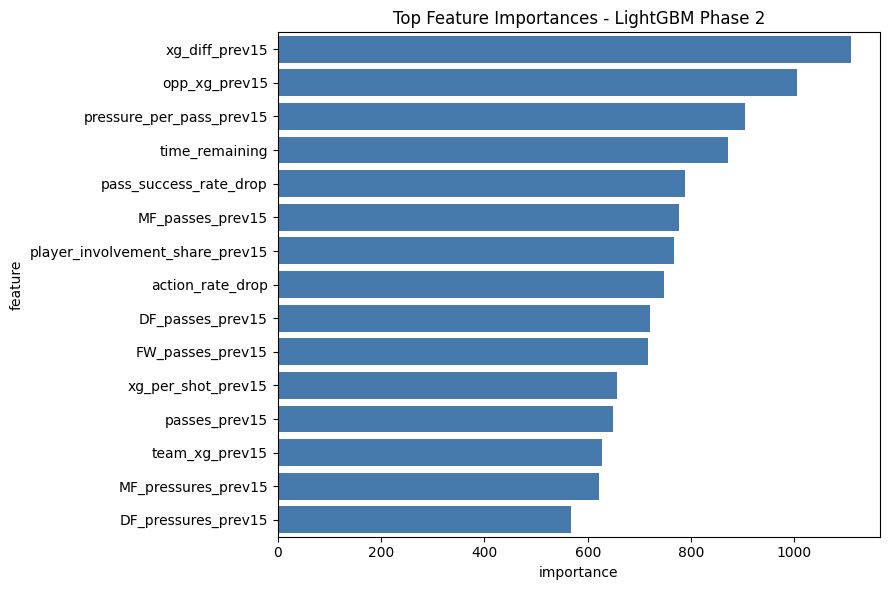

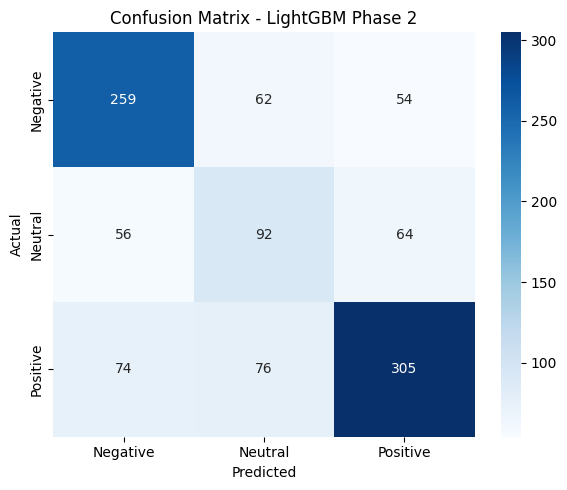


Saved Phase 2 handoff files:
outputs/substitutions_phase2_features.csv
outputs/phase2_best_gradient_boosting_model.pkl
outputs/phase2_best_model_metadata.json
outputs/phase2_feature_columns.csv
outputs/phase2_test_predictions.csv
outputs/phase2_feature_importance.csv
outputs/phase2_feature_importance.png
outputs/phase2_confusion_matrix.png


In [22]:
phase2_results_df = pd.DataFrame(phase2_results).drop_duplicates("model", keep="last")
phase2_results_df = phase2_results_df.sort_values(["macro_f1", "accuracy"], ascending=False)

print("\nPHASE 2 FINAL MODEL COMPARISON")
print(phase2_results_df.to_string(index=False))

best_model_name, best_info = max(
    trained_phase2_models.items(),
    key=lambda item: (item[1]["result"]["macro_f1"], item[1]["result"]["accuracy"])
)

best_model = best_info["model"]
best_pred = best_info["pred"]
best_prob = best_info["prob"]

print(f"\nBest Phase 2 model: {best_model_name}")
print(f"Best CV macro F1: {best_info['cv_best_macro_f1']:.4f}")
print("Best hyperparameters:")
print(best_info["best_params"])

model_bundle = {
    "model": best_model,
    "model_name": best_model_name,
    "feature_cols": ADVANCED_FEATURE_COLS,
    "label_encoder": le,
    "competition_map": competition_map,
}

joblib.dump(model_bundle, "outputs/phase2_best_gradient_boosting_model.pkl")

pd.DataFrame({"feature": ADVANCED_FEATURE_COLS}).to_csv(
    "outputs/phase2_feature_columns.csv", index=False
)

predictions_df = df_phase2.loc[X_test_p2.index, [
    "match_id", "competition", "team", "sub_minute",
    "outgoing_player", "replacement_player", "impact_label", "impact_score"
]].copy()

predictions_df["actual_label"] = le.inverse_transform(y_test_p2)
predictions_df["predicted_label"] = le.inverse_transform(best_pred)

for class_idx, class_name in enumerate(le.classes_):
    predictions_df[f"prob_{class_name}"] = best_prob[:, class_idx]

predictions_df.to_csv("outputs/phase2_test_predictions.csv", index=False)

metadata = {
    "best_model_name": best_model_name,
    "label_classes": list(le.classes_),
    "metrics": best_info["result"],
    "cv_best_macro_f1": float(best_info["cv_best_macro_f1"]),
    "best_params": best_info["best_params"],
    "feature_count": len(ADVANCED_FEATURE_COLS),
}

with open("outputs/phase2_best_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": ADVANCED_FEATURE_COLS,
        "importance": best_model.feature_importances_,
    }).sort_values("importance", ascending=False)

    importance_df.to_csv("outputs/phase2_feature_importance.csv", index=False)

    plt.figure(figsize=(9, 6))
    sns.barplot(data=importance_df.head(15), x="importance", y="feature", color="#357ABD")
    plt.title(f"Top Feature Importances - {best_model_name}")
    plt.tight_layout()
    plt.savefig("outputs/phase2_feature_importance.png", dpi=160)
    plt.show()

cm = confusion_matrix(y_test_p2, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.savefig("outputs/phase2_confusion_matrix.png", dpi=160)
plt.show()

print("\nSaved Phase 2 handoff files:")
print("outputs/substitutions_phase2_features.csv")
print("outputs/phase2_best_gradient_boosting_model.pkl")
print("outputs/phase2_best_model_metadata.json")
print("outputs/phase2_feature_columns.csv")
print("outputs/phase2_test_predictions.csv")
print("outputs/phase2_feature_importance.csv")
print("outputs/phase2_feature_importance.png")
print("outputs/phase2_confusion_matrix.png")